<img src="images/banner.png" style="width: 100%;">

In [1]:
import os
os.environ["KERAS_BACKEND"] = "torch"
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

import numpy as np
from numpy.testing import assert_array_equal, assert_almost_equal, assert_array_almost_equal

# Modern RNNs

In this notebook, we'll show how LSTM works by implementing it from scratch.

## 1 Sample Data

In [2]:
signal = np.array([3, 2, 1, 2, 3, 3, 3, 2, 2, 2, 3, 3, 3, 3, 2, 1, 2, 3, 3, 3,
                   1, 2, 2, 3, 2, 1]) - 2
signal

array([ 1,  0, -1,  0,  1,  1,  1,  0,  0,  0,  1,  1,  1,  1,  0, -1,  0,
        1,  1,  1, -1,  0,  0,  1,  0, -1])

In [3]:
sequence_length = 5
predictors = []
targets = []
for i in range(len(signal) - sequence_length):
    predictors.append(signal[i:i+sequence_length])
    targets.append(signal[i+sequence_length])
predictors = np.array(predictors)
targets = np.array(targets)

In [4]:
import tensorflow as tf

In [5]:
dataset = tf.data.Dataset.from_tensor_slices(
    (predictors.reshape((21, 5, 1)), targets)
)

## 2 LSTM Implementation from Scratch

In [6]:
import keras
from keras import ops
from keras import layers
from keras import activations
from keras import initializers

In [7]:
class LSTMScratch(layers.Layer):
    def __init__(self, num_inputs, num_hiddens, sigma=0.01):
        super().__init__()

        self.num_inputs = num_inputs
        self.num_hiddens = num_hiddens

        # Input Gate
        self.U_I = self.add_weight(
            shape=(num_inputs, num_hiddens),
            initializer=initializers.RandomNormal(stddev=sigma))
        self.W_I = self.add_weight(
            shape=(num_hiddens, num_hiddens),
            initializer=initializers.RandomNormal(stddev=sigma))
        self.b_I = self.add_weight(shape=(num_hiddens,), initializer="zeros")

        # Forget Gate
        self.U_F = self.add_weight(
            shape=(num_inputs, num_hiddens),
            initializer=initializers.RandomNormal(stddev=sigma))
        self.W_F = self.add_weight(
            shape=(num_hiddens, num_hiddens),
            initializer=initializers.RandomNormal(stddev=sigma))
        self.b_F = self.add_weight(shape=(num_hiddens,), initializer="zeros")

        # Output Gate
        self.U_O = self.add_weight(
            shape=(num_inputs, num_hiddens),
            initializer=initializers.RandomNormal(stddev=sigma))
        self.W_O = self.add_weight(
            shape=(num_hiddens, num_hiddens),
            initializer=initializers.RandomNormal(stddev=sigma))
        self.b_O = self.add_weight(shape=(num_hiddens,), initializer="zeros")

        # Candidate State
        self.U_C = self.add_weight(
            shape=(num_inputs, num_hiddens),
            initializer=initializers.RandomNormal(stddev=sigma))
        self.W_C = self.add_weight(
            shape=(num_hiddens, num_hiddens),
            initializer=initializers.RandomNormal(stddev=sigma))
        self.b_C = self.add_weight(shape=(num_hiddens,), initializer="zeros")

    def call(self, inputs, H_C=None):
        if H_C is None:
            # Initial state with shape
            H = ops.zeros((self.num_hiddens,))
            C = ops.zeros((self.num_hiddens,))
        else:
            H, C = H_C

        # Forward propagation
        outputs = []
        for X in inputs:
            for x in X:
                I = activations.sigmoid(
                    ops.matmul(x, self.U_I) + ops.matmul(H, self.W_I) + self.b_I)
                F = activations.sigmoid(
                    ops.matmul(x, self.U_F) + ops.matmul(H, self.W_F) + self.b_F)
                O = activations.sigmoid(
                    ops.matmul(x, self.U_O) + ops.matmul(H, self.W_O) + self.b_O)
                C_tilde = activations.tanh(
                    ops.matmul(x, self.U_C) + ops.matmul(H, self.W_C) + self.b_C)
                C = F*C + I*C_tilde
                H = O * activations.tanh(C)
            outputs.append(H)

        return ops.concatenate(outputs).reshape((-1, self.num_hiddens))

In [8]:
inputs = keras.Input(shape=(5, 1))
x = LSTMScratch(num_inputs=1, num_hiddens=10)(inputs)
outputs = layers.Dense(1, activation="tanh")(x)
model = keras.Model(inputs, outputs)

In [9]:
from keras import optimizers

In [10]:
callbacks = [
    keras.callbacks.ModelCheckpoint("lstm_scratch.keras")
]
model.compile(optimizer=optimizers.Adam(learning_rate=0.01), loss="mse",
              metrics=["mae"])

In [ ]:
history = model.fit(
    dataset,
    epochs=200,
    callbacks=callbacks,
)

In [12]:
from utils import plot_history

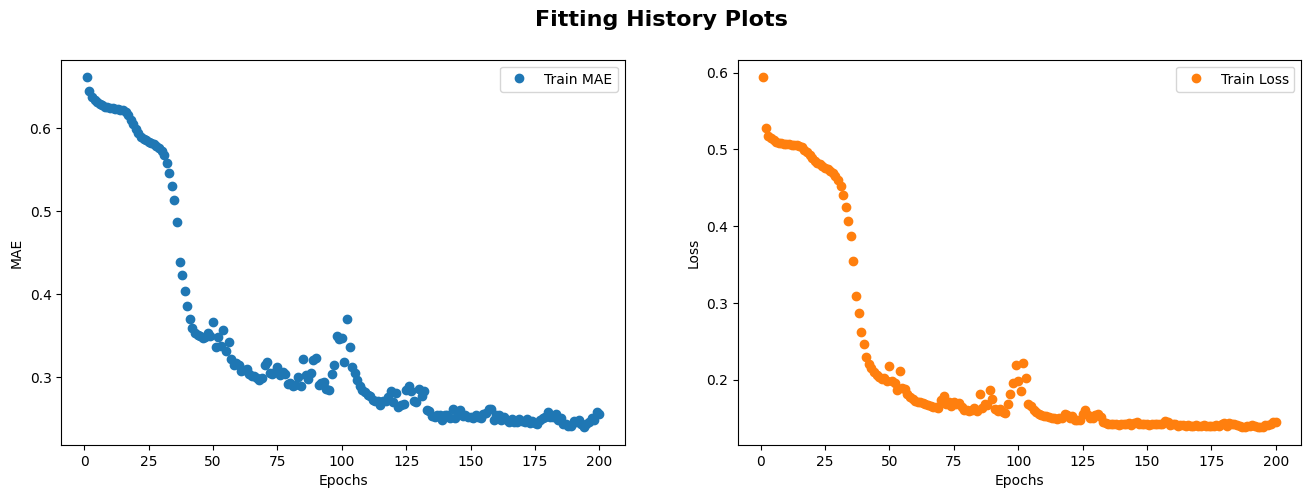

In [13]:
plot_history(history);

In [ ]:
predictions = []
for X in predictors:
    prediction = model.predict(X.reshape((1, 5, 1)))
    predictions.append(prediction)

In [15]:
rounded_predictions = np.array(predictions).flatten().round().astype(int)
rounded_predictions

array([ 1,  1, -1,  0,  0,  1,  1,  1,  1,  0, -1,  0,  1,  1,  1, -1,  0,
        0,  1,  0, -1])

In [16]:
targets

array([ 1,  1,  0,  0,  0,  1,  1,  1,  1,  0, -1,  0,  1,  1,  1, -1,  0,
        0,  1,  0, -1])

In [17]:
np.abs(rounded_predictions - targets).mean()

np.float64(0.047619047619047616)

<img src="images/banner-down.png" style="width: 100%;">